# Проверка статистических гипотез о наличии связи

### Выбор теста

| Задача | Тест |
|---|---|
| Среднее против конкретного числа | Одновыборочный t-тест |
| Средние двух независимых групп | t-тест для независимых выборок |
| Средние до/после | Парный t-тест |
| Одна доля против константы | Z-тест для доли |
| Две доли | Z-тест для двух долей |
| ✅ Связь категориальных переменных | Хи-квадрат |
| Две независимые группы без нормальности | Манн–Уитни |
| Две связанные группы без нормальности | Уилкоксон |

## Хи-квадрат: связь между категориальными переменными

Критерий хи-квадрат используется, когда нужно проверить связь между двумя категориальными признаками.

**Пример задачи**

Проверить, связаны ли пол пользователя и выбор тарифа.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats

Исходные данные:

In [2]:
table = pd.DataFrame({
    "Базовый": [40, 30],
    "Премиум": [20, 35]
}, index=["Мужчины", "Женщины"])

table

,Базовый,Премиум
Мужчины,40,20
Женщины,30,35


Стат. тест: 

In [3]:
chi2_stat, p_value, dof, expected = stats.chi2_contingency(table)

print(f"chi2-статистика: {chi2_stat:.3f}")
print(f"p-value: {p_value:.5f}")
print(f"Степени свободы: {dof}")

chi2-статистика: 4.528
p-value: 0.03334
Степени свободы: 1


**Интерпретация**

In [5]:
alpha = 0.05

if p_value <= alpha:
    print("Между переменными есть статистически значимая связь")
else:
    print("Нет оснований считать, что переменные связаны")

Между переменными есть статистически значимая связь


Также можно вывести ожидаемые частоты

In [7]:
print("Ожидаемые частоты:")
print(expected)

Ожидаемые частоты:
[[32.41935484 27.58064516]
 [34.58064516 29.41935484]]


## Визуализация

Далее можем увидеть, куда попадает значение статистики – в область правого хвоста распределения ЗА критическим значением.

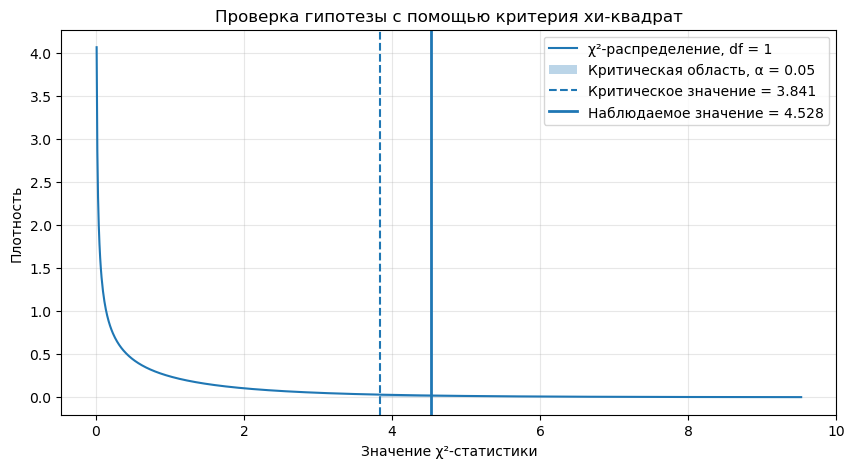

In [8]:
import matplotlib.pyplot as plt

# Критическое значение для правого хвоста
critical_value = stats.chi2.ppf(1 - alpha, dof)

# Значения для построения распределения
x = np.linspace(0, max(chi2_stat, critical_value) + 5, 1000)
y = stats.chi2.pdf(x, dof)

plt.figure(figsize=(10, 5))

# Самоаспределение хи-квадрат
plt.plot(x, y, label=f"χ²-распределение, df = {dof}")

# Критическая область
x_crit = x[x >= critical_value]
y_crit = stats.chi2.pdf(x_crit, dof)

plt.fill_between(
    x_crit,
    y_crit,
    alpha=0.3,
    label=f"Критическая область, α = {alpha}"
)

# Критическое значение
plt.axvline(
    critical_value,
    linestyle="--",
    label=f"Критическое значение = {critical_value:.3f}"
)

# Наблюдаемое значение
plt.axvline(
    chi2_stat,
    linestyle="-",
    linewidth=2,
    label=f"Наблюдаемое значение = {chi2_stat:.3f}"
)

plt.title("Проверка гипотезы с помощью критерия хи-квадрат")
plt.xlabel("Значение χ²-статистики")
plt.ylabel("Плотность")
plt.legend()
plt.grid(alpha=0.3)

plt.show()